# Cross-entropy method

Learn the cross-entropy method on discrete Taxi states, then use a neural-network policy for CartPole.

This exercise targets Python 3.12+:

```bash
python -m pip install "gymnasium[classic-control]>=1.3,<2" numpy matplotlib scikit-learn ipython
```


In [94]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output

%matplotlib inline


In [95]:
env = gym.make("Taxi-v4", render_mode="ansi")
observation, info = env.reset()
print(env.render())


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [96]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print("n_states=%i, n_actions=%i"%(n_states,n_actions))

n_states=500, n_actions=6


# Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize policy __uniformly__, that is, probabililities of all actions should be equal.


# Initialize policy (0.5pts)

In [97]:
policy = np.full((n_states, n_actions), 1.0 / n_actions)
assert isinstance(policy, np.ndarray)
assert np.allclose(policy, 1.0 / n_actions)
assert np.allclose(np.sum(policy, axis=1), 1.0)
print("Ok!")


Ok!


# Play the game (0.5pts)

Just like before, but we also record all states and actions we took.

In [98]:
def generate_session(policy, t_max=10**4):
    """Return a Taxi episode's states, actions, and total reward."""
    states, actions = [], []
    total_reward = 0.0
    state, info = env.reset()

    for _ in range(t_max):
        action = np.random.choice(n_actions, p=policy[state])
        next_state, reward, terminated, truncated, info = env.step(action)

        states.append(state)
        actions.append(action)
        total_reward += reward

        state = next_state
        if terminated or truncated:
            break

    return states, actions, total_reward

In [99]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [100]:
states, actions, reward = generate_session(policy)
assert isinstance(states, list) and isinstance(actions, list)
assert len(states) == len(actions)
assert isinstance(reward, (float, np.floating))


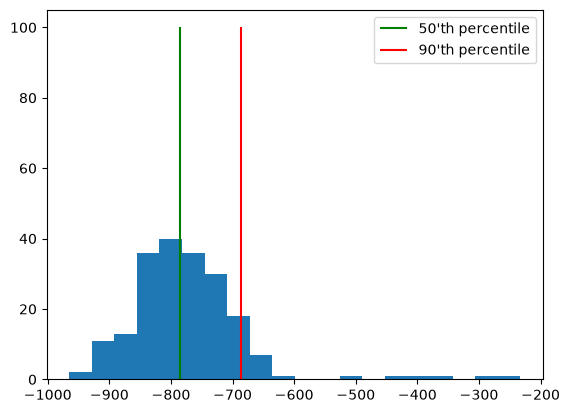

In [101]:
#let's see the initial reward distribution
import matplotlib.pyplot as plt
%matplotlib inline

sample_rewards = [generate_session(policy,t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards,bins=20);
plt.vlines([np.percentile(sample_rewards,50)],[0],[100],label="50'th percentile",color='green')
plt.vlines([np.percentile(sample_rewards,90)],[0],[100],label="90'th percentile",color='red')
plt.legend()

### Crossentropy method steps (1pts)

In [102]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_session_indices = []
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_session_indices.append(i)

    elite_states, elite_actions = [], []
    for i in elite_session_indices:
        for state in states_batch[i]:
            elite_states.append(state)
        for action in actions_batch[i]:
            elite_actions.append(action)

    elite_states = np.array(elite_states)
    elite_actions = np.array(elite_actions)
    return elite_states, elite_actions

In [103]:
states_batch = [
    [1, 2, 3],       # game 1
    [4, 2, 0, 2],    # game 2
    [3, 1],          # game 3
]
actions_batch = [
    [0, 2, 4],       # game 1
    [3, 2, 0, 1],    # game 2
    [3, 3],          # game 3
]
rewards_batch = np.array([3, 4, 5])

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.array_equal(test_result_0[0], [1, 2, 3, 4, 2, 0, 2, 3, 1])
assert np.array_equal(test_result_0[1], [0, 2, 4, 3, 2, 0, 1, 3, 3])
assert np.array_equal(test_result_30[0], [4, 2, 0, 2, 3, 1])
assert np.array_equal(test_result_30[1], [3, 2, 0, 1, 3, 3])
assert np.array_equal(test_result_90[0], [3, 1])
assert np.array_equal(test_result_90[1], [3, 3])
assert np.array_equal(test_result_100[0], [3, 1])
assert np.array_equal(test_result_100[1], [3, 3])
print("Ok!")


Ok!


In [104]:
def update_policy(elite_states, elite_actions):
    new_policy = np.zeros([n_states, n_actions])

    np.add.at(new_policy, (elite_states, elite_actions), 1)

    row_sums = new_policy.sum(axis=1, keepdims=True)
    visited = row_sums[:, 0] > 0
    new_policy[visited] /= row_sums[visited]

    new_policy[~visited] = 1.0 / n_actions
    return new_policy

In [105]:

elite_states, elite_actions = ([1, 2, 3, 4, 2, 0, 2, 3, 1], [0, 2, 4, 3, 2, 0, 1, 3, 3])


new_policy = update_policy(elite_states,elite_actions)

assert np.isfinite(new_policy).all(), "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(new_policy>=0), "Your new policy can't have negative action probabilities"
assert np.allclose(new_policy.sum(axis=-1),1), "Your new policy should be a valid probability distribution over actions"
reference_answer = np.array([
       [ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.5       ,  0.        ,  0.        ,  0.5       ,  0.        ],
       [ 0.        ,  0.33333333,  0.66666667,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.5       ,  0.5       ]])
print(new_policy[:4,:5])
assert np.allclose(new_policy[:4,:5],reference_answer)
print("Ok!")

[[1.         0.         0.         0.         0.        ]
 [0.5        0.         0.         0.5        0.        ]
 [0.         0.33333333 0.66666667 0.         0.        ]
 [0.         0.         0.         0.5        0.5       ]]
Ok!


# Training loop (1pts)
Generate sessions, select N best and fit to those.

In [106]:
def show_progress(rewards_batch, log, percentile, reward_range=None):
    """Display the mean reward and elite threshold during training."""
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append((mean_reward, threshold))

    clear_output(wait=True)
    print(f"mean reward = {mean_reward:.3f}, threshold = {threshold:.3f}")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].plot([row[0] for row in log], label="Mean reward")
    axes[0].plot([row[1] for row in log], label="Elite threshold")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Reward")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].hist(rewards_batch, bins=20, range=reward_range)
    axes[1].axvline(threshold, label="Elite threshold", color="red")
    axes[1].set_xlabel("Episode reward")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()


mean reward = 7.064, threshold = 4.000


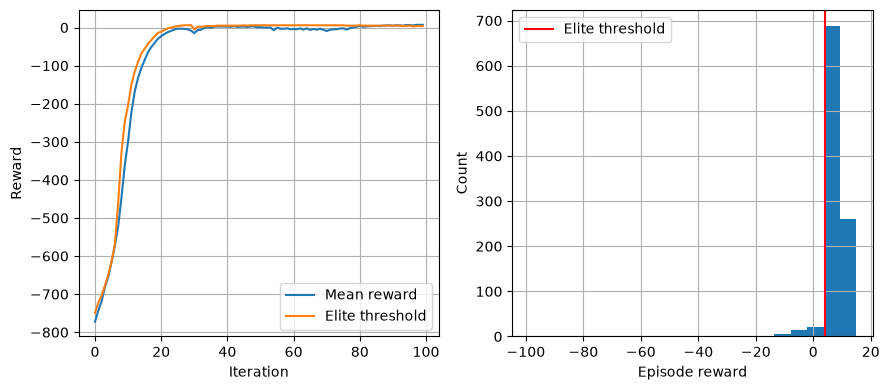

0.0
6.464397827504867


In [107]:
policy = np.full((n_states, n_actions), 1.0 / n_actions)
import math
n_sessions = 1000
percentile = 30
log = []

temp = 100
temp2 = 100
x = 0.8
x2 = 0.95

print(math.exp(-1/temp))
print(math.exp(-1/temp2) * 70)

for iteration in range(100):
    temp *= x
    temp2 *= x2
    learning_rate = 0.3
    if (iteration < 30):
        percentile = math.exp(-1/temp2) * 70
    else:
        percentile = math.exp(-1/temp2) * 35
    sessions = [generate_session(policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )
    new_policy = update_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)

print(math.exp(-1/temp))
print(math.exp(-1/temp2) * 35)

# Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (1 pts) Find out how the algorithm performance changes if you change different percentile and different n_samples. - Build graph with different percentiles on the same graph. And second one for sample size
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


In [38]:
env.close()
env = gym.make("Taxi-v4")
state, info = env.reset()
n_states = env.observation_space.n
n_actions = env.action_space.n
policy = np.full((n_states, n_actions), 1.0 / n_actions)

assert isinstance(policy, np.ndarray)
assert np.allclose(policy.sum(axis=1), 1.0)
states, actions, reward = generate_session(policy)
assert isinstance(states, list) and isinstance(actions, list)
assert len(states) == len(actions)
assert isinstance(reward, (float, np.floating))
step_counter = 40


In [39]:
n_sessions = 250
percentiles = [10, 30, 50, 70, 90]
learning_rate = 0.5
mean_rewards_by_percentile = []

for percentile in percentiles:
    policy = np.full((n_states, n_actions), 1.0 / n_actions)
    current_means = []
    for iteration in range(step_counter):
        sessions = [generate_session(policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile=percentile
        )
        new_policy = update_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        current_means.append(np.mean(rewards_batch))
    mean_rewards_by_percentile.append(current_means)

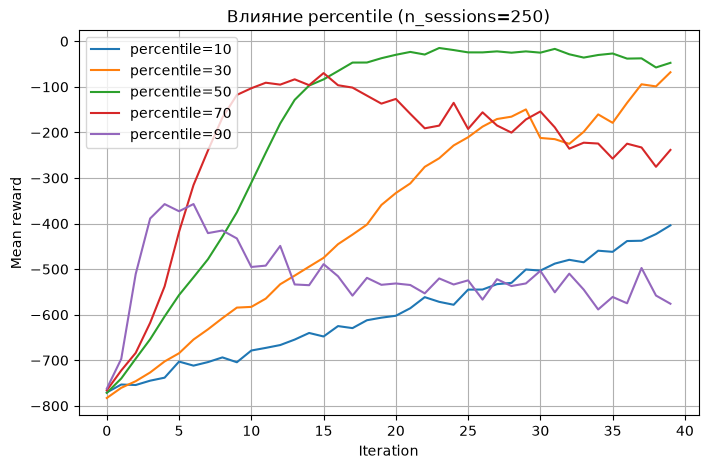

In [40]:
plt.figure(figsize=(8, 5))
for percentile, means in zip(percentiles, mean_rewards_by_percentile):
    plt.plot(means, label=f"percentile={percentile}")
plt.xlabel("Iteration")
plt.ylabel("Mean reward")
plt.title("Влияние percentile (n_sessions=250)")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
session_counts = [50, 100, 250, 500]
percentile = 70
learning_rate = 0.5
mean_rewards_by_session_count = []

for n_sessions in session_counts:
    policy = np.full((n_states, n_actions), 1.0 / n_actions)
    current_means = []
    for iteration in range(step_counter):
        sessions = [generate_session(policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile=percentile
        )
        new_policy = update_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        current_means.append(np.mean(rewards_batch))
    mean_rewards_by_session_count.append(current_means)

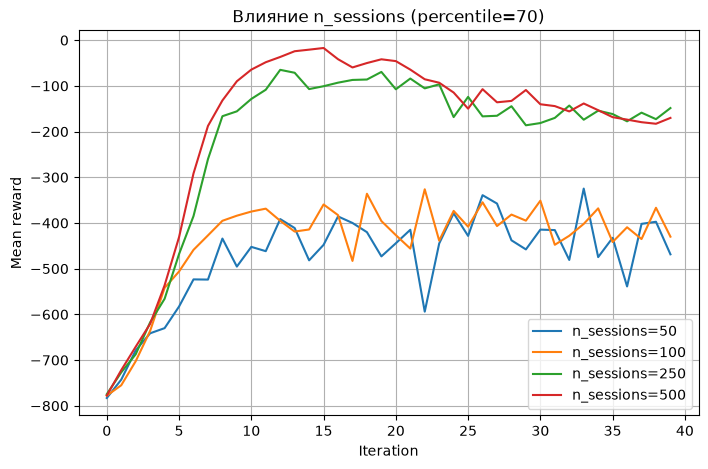

In [42]:
plt.figure(figsize=(8, 5))
for n, means in zip(session_counts, mean_rewards_by_session_count):
    plt.plot(means, label=f"n_sessions={n}")
plt.xlabel("Iteration")
plt.ylabel("Mean reward")
plt.title("Влияние n_sessions (percentile=70)")
plt.legend()
plt.grid(True)
plt.show()

# Stabilize positive rewards by averaging policy across 10 games (2 pts)

In [108]:
def generate_session(policy, t_max=10**4, n_games=10):
    """Return states, actions and total reward for n_games Taxi episodes."""
    states, actions = [], []
    total_reward = 0.0

    for _ in range(n_games):
        state, info = env.reset()
        for _ in range(t_max):
            action = np.random.choice(n_actions, p=policy[state])
            next_state, reward, terminated, truncated, info = env.step(action)

            states.append(state)
            actions.append(action)
            total_reward += reward

            state = next_state
            if terminated or truncated:
                break
    total_reward /= n_games
    return states, actions, total_reward

mean reward = 4.468, threshold = 5.940


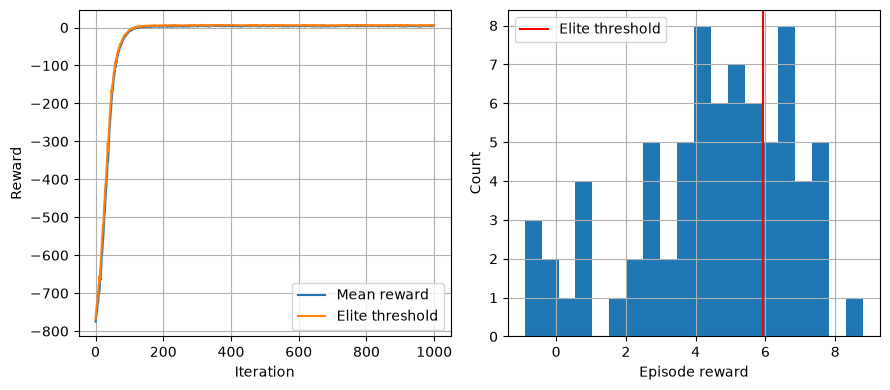

In [109]:
n_sessions = 75
percentile = 70
learning_rate = 0.2
log = []
mean = []
policy = np.full((n_states, n_actions), 1.0 / n_actions)

for iteration in range(1000):
    sessions = [generate_session(policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )
    new_policy = update_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    mean.append(np.mean(rewards_batch))
    show_progress(rewards_batch, log, percentile)
    if np.mean(rewards_batch) > 10:
        print("win!")
        break

mean reward = -1.536, threshold = -4.400


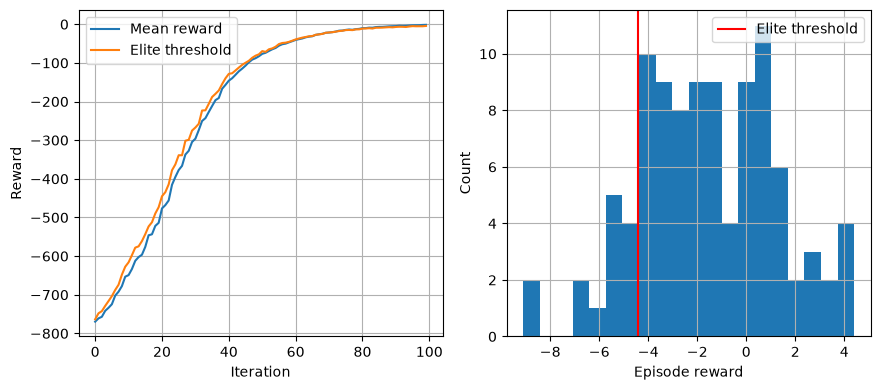

In [111]:
import math
n_sessions = 100
temp = 100
temp2 = 100
x = 0.8
x2 = 0.95
log = []
mean = []
policy = np.full((n_states, n_actions), 1.0 / n_actions)

for iteration in range(100):
    temp *= x
    temp2 *= x2
    learning_rate = 0.3
    if (iteration < 300):
        percentile = math.exp(-1/temp2) * 70
    else:
        percentile = math.exp(-1/temp2) * 35
    sessions = [generate_session(policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )
    new_policy = update_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    mean.append(np.mean(rewards_batch))
    show_progress(rewards_batch, log, percentile)
    if np.mean(rewards_batch) > 10:
        print("win!")
        break

mean reward = 7.538, threshold = 6.480


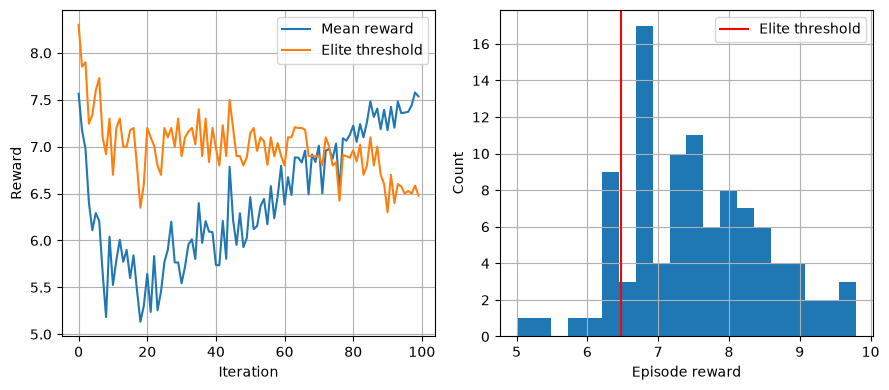

0.0
13.852281058939


In [116]:
import math
n_sessions = 100
percentile = 30
log = []

temp = 100
temp2 = 100
x = 0.8
x2 = 0.95

print(math.exp(-1/temp))
print(math.exp(-1/temp2) * 70)

for iteration in range(100):
    temp *= x
    temp2 *= x2
    learning_rate = 0.3
    percentile = math.exp(-1/temp2) * 70
    sessions = [generate_session(policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )
    new_policy = update_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)

print(math.exp(-1/temp))
print(math.exp(-1/temp2) * 75)

Количество иттераций для достжения положительного результата возросло, но модель не только достигает большей положительной награды, но и стабильно сохраняет его.

# Digging deeper: approximate crossentropy with neural nets (2 pts)

In this section we will train a neural network policy for continuous state space game

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

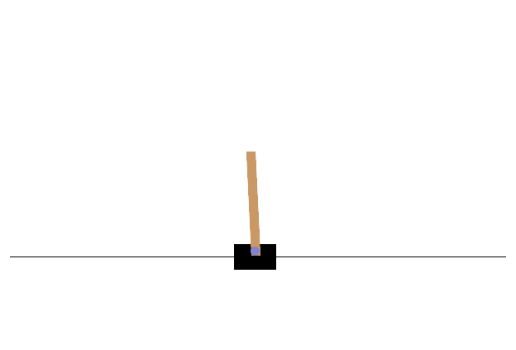

In [117]:
env.close()
env = gym.make("CartPole-v1", render_mode="rgb_array")
initial_observation, info = env.reset()
n_actions = env.action_space.n
plt.imshow(env.render())
plt.axis("off")


In [118]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
    warm_start=True,
    max_iter=1,
)
initial_observation, info = env.reset()
agent.fit(
    np.repeat(initial_observation[None, :], n_actions, axis=0),
    np.arange(n_actions),
)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previouscall to fit as initialization, otherwise, just erase theprevious solution. See :term:`the Glossary <warm_start>`.",True
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [119]:
def generate_session(t_max=1000):
    """Return a CartPole episode's states, actions, and total reward."""
    states, actions = [], []
    total_reward = 0.0
    state, info = env.reset()

    for _ in range(t_max):
        probs = agent.predict_proba(state[None, :])[0]
        action = np.random.choice(n_actions, p=probs)
        next_state, reward, terminated, truncated, info = env.step(action)

        states.append(state)
        actions.append(action)
        total_reward += reward

        state = next_state
        if terminated or truncated:
            break

    return states, actions, total_reward

In [120]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """Select elite sessions without constructing ragged NumPy arrays."""
    threshold = np.percentile(rewards_batch, percentile)
    selected = [
        index for index, reward in enumerate(rewards_batch)
        if reward >= threshold
    ]
    elite_states = np.concatenate(
        [np.asarray(states_batch[index]) for index in selected], axis=0
    )
    elite_actions = np.concatenate(
        [np.asarray(actions_batch[index]) for index in selected], axis=0
    )
    return elite_states, elite_actions


mean reward = 213.450, threshold = 240.200


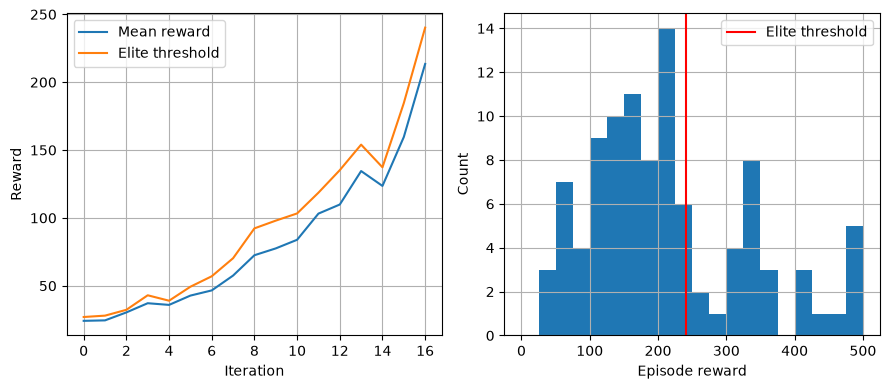

You win! You may stop training now.


In [121]:
n_sessions = 100
percentile = 70
log = []

for iteration in range(100):
    sessions = [generate_session() for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile=percentile
    )
    agent.fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, percentile, reward_range=(0, 500))
    if np.mean(rewards_batch) > 190:
        print("You win! You may stop training now.")
        break

# Report (1 pts)

# Report

## Что сделано

**Taxi (таблица).** Политика это таблица `policy[s, a]` с вероятностями действий, в начале равномерная. Метод повторяет цикл: играем эпизоды, оставляем лучшие (`select_elites`), считаем в них частоты действий (`update_policy`) и смешиваем новую политику со старой через `learning_rate`, чтобы она менялась плавно.

**Эксперименты (1.1).** Высокий percentile (90) оставляет слишком мало данных, и обучение шумное. Очень низкий (10) почти не отбирает лучших, и обучение медленное. Больше `n_sessions` даёт более ровную и высокую кривую, но итерации идут дольше.

**Положительная награда (1.2).** Использовали идею отжига: `percentile` не постоянный, а меняется по графику «остывания». Температура уменьшается каждую итерацию (`temp2 *= 0.95`), а `percentile = exp(-1/temp2) * 70`. Остальное зафиксировано: `n_sessions=100`, `learning_rate=0.3`.

**Усреднение по 10 играм.** Награда одной игры зависит от везения со стартом, поэтому сессия теперь состоит из 10 игр. Положительный результат появился на итерации [ваше число] и держится стабильнее.

**CartPole (нейросеть).** Состояний бесконечно много, поэтому политику задаёт `MLPClassifier`: он учится предсказывать действия из лучших эпизодов (`agent.fit`). Порог 190 достигнут за [ваше число] итераций.

## Вывод

Главная проблема метода в шуме из-за случайности среды. Его уменьшают больше эпизодов, мягкий отбор, малый `learning_rate` и усреднение по нескольким играм.